In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("../data/raw/dataset-6ab002b01f9ef078223946.csv")

In [65]:
df.shape

(6607, 20)

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [67]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [68]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [69]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [70]:
df.duplicated().sort_values(ascending=False)

0       False
4401    False
4411    False
4410    False
4409    False
        ...  
2199    False
2198    False
2197    False
2196    False
6606    False
Length: 6607, dtype: bool

In [71]:
df.value_counts("Internet_Access").sort_index()

Internet_Access
No      499
Yes    6108
Name: count, dtype: int64

In [72]:
df.value_counts("Exam_Score")

Exam_Score
68     759
66     751
67     717
65     679
69     624
70     542
64     501
71     408
63     371
72     304
62     264
61     171
73     141
74     106
60      77
75      48
59      40
58      22
76      16
80       5
77       5
78       4
86       4
94       4
82       4
57       4
79       3
89       3
97       3
84       3
88       3
98       3
92       2
99       2
87       2
95       2
93       2
100      1
83       1
55       1
101      1
91       1
96       1
85       1
56       1
Name: count, dtype: int64

In [73]:
df[df["Exam_Score"]==101] #to drop

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [74]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [75]:
teacher_quality_mode = df["Teacher_Quality"].mode()
teacher_quality_mode

0    Medium
Name: Teacher_Quality, dtype: str

In [76]:
Parental_Education_Level_mode = df["Parental_Education_Level"].mode()
Parental_Education_Level_mode

0    High School
Name: Parental_Education_Level, dtype: str

In [77]:
Distance_from_Home_mode = df["Distance_from_Home"].mode()
Distance_from_Home_mode

0    Near
Name: Distance_from_Home, dtype: str

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [79]:
df[["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores","Tutoring_Sessions","Physical_Activity","Exam_Score"]].mean()

Hours_Studied        19.975329
Attendance           79.977448
Sleep_Hours           7.029060
Previous_Scores      75.070531
Tutoring_Sessions     1.493719
Physical_Activity     2.967610
Exam_Score           67.235659
dtype: float64

In [80]:
df[["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores","Tutoring_Sessions","Physical_Activity","Exam_Score"]].median()

Hours_Studied        20.0
Attendance           80.0
Sleep_Hours           7.0
Previous_Scores      75.0
Tutoring_Sessions     1.0
Physical_Activity     3.0
Exam_Score           67.0
dtype: float64

In [81]:
df[["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores","Tutoring_Sessions","Physical_Activity","Exam_Score"]].std()

Hours_Studied         5.990594
Attendance           11.547475
Sleep_Hours           1.468120
Previous_Scores      14.399784
Tutoring_Sessions     1.230570
Physical_Activity     1.031231
Exam_Score            3.890456
dtype: float64

In [82]:
df.duplicated().sum()

np.int64(0)

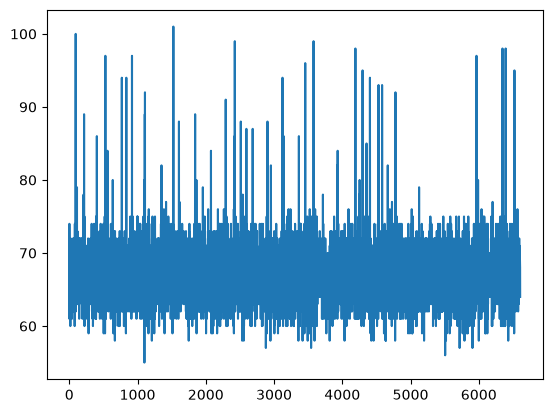

In [83]:
plt.plot(df["Exam_Score"])
plt.show()

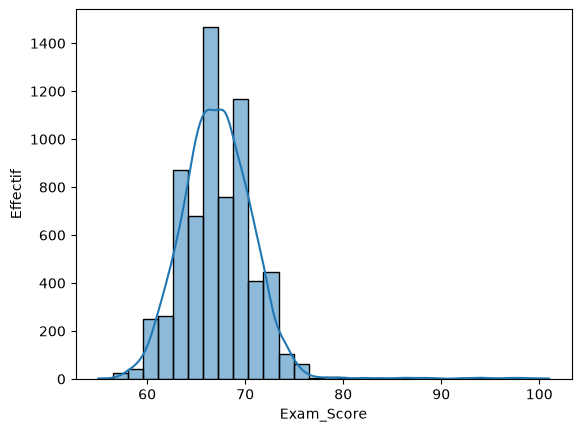

In [84]:

sns.histplot(df["Exam_Score"], bins=30, kde=True)
plt.xlabel("Exam_Score")
plt.ylabel("Effectif")
plt.show()

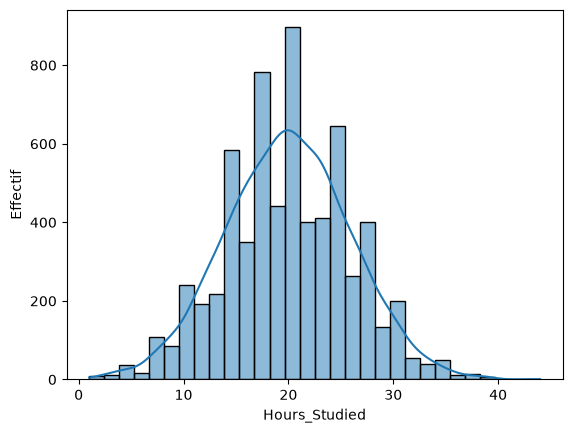

In [85]:
sns.histplot(df["Hours_Studied"], bins=30, kde=True)
plt.xlabel("Hours_Studied")
plt.ylabel("Effectif")
plt.show()

In [86]:
df_clean = df.copy()

In [87]:
cols_mode = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for col in cols_mode:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [88]:
n_dup = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

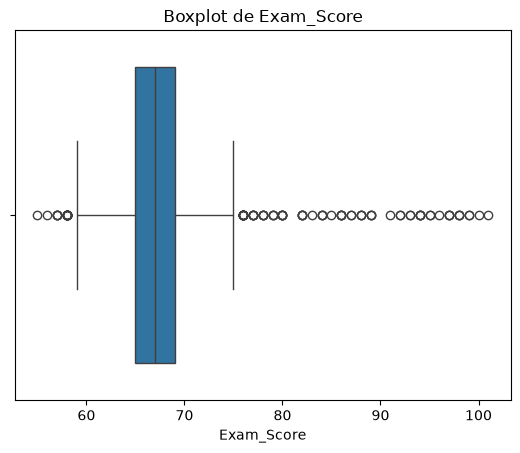

In [89]:
sns.boxplot(x=df_clean["Exam_Score"])
plt.title("Boxplot de Exam_Score")
plt.show()

In [90]:
q1, q3 = df_clean["Exam_Score"].quantile([0.25, 0.75])
iqr = q3 - q1
borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Bornes IQR : [{borne_basse}, {borne_haute}]")
est_outlier_iqr = (df_clean["Exam_Score"] < borne_basse) | (df_clean["Exam_Score"] > borne_haute)

Q1=65.0, Q3=69.0, IQR=4.0
Bornes IQR : [59.0, 75.0]


In [91]:
z = stats.zscore(df_clean["Exam_Score"])
est_outlier_z = np.abs(z) > 3

In [ ]:
df_clean = df_clean[~est_outlier_iqr].reset_index(drop=True)

In [93]:
ordre_lmh = {"Low": 0, "Medium": 1, "High": 2}
mappings_ordinaux = {
    "Parental_Involvement": ordre_lmh,
    "Access_to_Resources": ordre_lmh,
    "Motivation_Level": ordre_lmh,
    "Family_Income": ordre_lmh,
    "Teacher_Quality": ordre_lmh,
    "Parental_Education_Level": {"High School": 0, "College": 1, "Postgraduate": 2},
    "Distance_from_Home": {"Near": 0, "Moderate": 1, "Far": 2},
}
cols_nominales = ["Gender", "School_Type", "Extracurricular_Activities",
                  "Internet_Access", "Learning_Disabilities", "Peer_Influence"]

df_enc = df_clean.copy()
for col, mapping in mappings_ordinaux.items():
    df_enc[col] = df_enc[col].map(mapping)

df_enc = pd.get_dummies(df_enc, columns=cols_nominales, drop_first=True, dtype=int)
df_enc.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,School_Type_Public,Extracurricular_Activities_Yes,Internet_Access_Yes,Learning_Disabilities_Yes,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,0,2,7,73,0,0,0,1,...,0,0,67,1,1,0,1,0,0,1
1,19,64,0,1,8,59,0,2,1,1,...,1,1,61,0,1,0,1,0,0,0
2,24,98,1,1,7,91,1,2,1,1,...,2,0,74,1,1,1,1,0,1,0
3,29,89,0,1,8,98,1,1,1,1,...,0,1,71,1,1,1,1,0,0,0
4,19,92,1,1,6,65,1,3,1,2,...,1,0,70,0,1,1,1,0,1,0


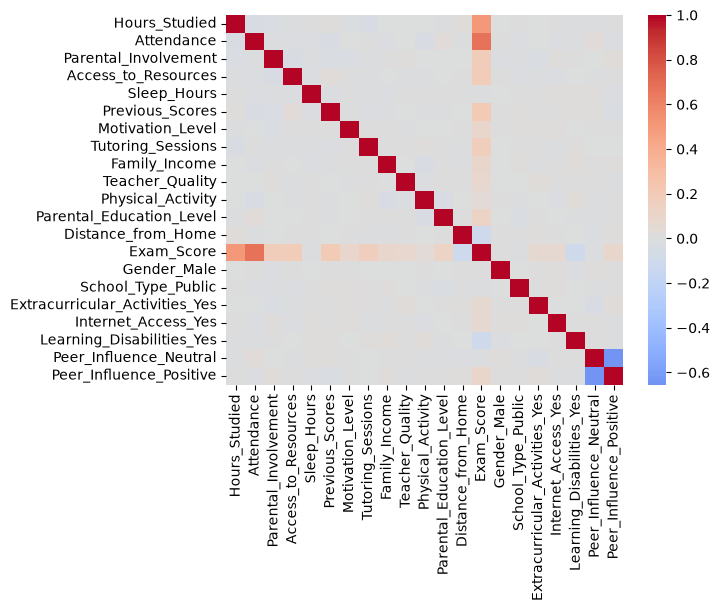

Attendance                        0.673871
Hours_Studied                     0.500724
Previous_Scores                   0.199112
Access_to_Resources               0.187986
Parental_Involvement              0.175488
Tutoring_Sessions                 0.168462
Parental_Education_Level          0.124967
Motivation_Level                  0.094466
Family_Income                     0.094238
Peer_Influence_Positive           0.093225
Teacher_Quality                   0.079875
Extracurricular_Activities_Yes    0.066235
Internet_Access_Yes               0.066185
Physical_Activity                 0.035787
Gender_Male                       0.006656
Peer_Influence_Neutral           -0.012300
Sleep_Hours                      -0.012496
School_Type_Public               -0.012607
Distance_from_Home               -0.098926
Learning_Disabilities_Yes        -0.102935
Name: Exam_Score, dtype: float64

In [95]:

sns.heatmap(df_enc.corr(), cmap="coolwarm", center=0)
plt.show()

df_enc.corr()["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)